## **A Comparative Study of Machine Learning Algorithms for Movie Recommendation Systems**

#### **Data Downloading**

In [72]:
!pip install -q kaggle

In [73]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"efficient8","key":"0e26061c5d5cf73b850e01f7c6575016"}'}

In [74]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [75]:
!kaggle datasets download -d tmdb/tmdb-movie-metadata

Dataset URL: https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata
License(s): other
tmdb-movie-metadata.zip: Skipping, found more recently modified local copy (use --force to force download)


In [76]:
!unzip -q tmdb-movie-metadata.zip

replace tmdb_5000_credits.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


## **Data Loading**

In [77]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [78]:
# Define the convert function here to make the cell self-contained
def convert(text):
    L = []
    try:
        for i in ast.literal_eval(text):
            L.append(i['name'])
    except (ValueError, SyntaxError):
        pass
    return L

In [79]:
original_movies_raw = pd.read_csv("tmdb_5000_movies.csv")
original_credits_raw = pd.read_csv("tmdb_5000_credits.csv", engine="python")

## **Preprocesing**

In [80]:
full_original_data = pd.merge(original_movies_raw, original_credits_raw, on='title', suffixes=('_movie', '_credit'))

In [81]:
full_original_data['genres_processed'] = full_original_data['genres'].apply(convert)

In [82]:
essential_cols_from_original = full_original_data[['movie_id', 'title', 'vote_average', 'vote_count', 'genres_processed']].copy()
essential_cols_from_original.rename(columns={'genres_processed': 'genres'}, inplace=True) # Only rename genres

In [83]:
new_df_enhanced = pd.merge(new[['movie_id', 'title', 'tags']], essential_cols_from_original, on=['movie_id', 'title'], how='left')

In [84]:
new = new_df_enhanced

## **Models**

#### **Content Based Recommendation**

In [85]:
class ContentBasedRecommender:
    def __init__(self, df, similarity_matrix, feature_vector_matrix, n=5):
        self.df = df
        self.similarity_matrix = similarity_matrix
        self.feature_vector_matrix = feature_vector_matrix
        self.n = n

    def recommend(self, movie_title):
        if movie_title not in self.df['title'].values:
            return pd.DataFrame()

        movie_index = self.df[self.df['title'] == movie_title].index[0]
        distances = sorted(list(enumerate(self.similarity_matrix[movie_index])), reverse=True, key=lambda x: x[1])

        recommended_movies_indices = [i[0] for i in distances[1:self.n+1]]

        recommendations = self.df.iloc[recommended_movies_indices]
        return recommendations

#### **Popularity Recommender**

In [86]:
class PopularityRecommender:
    def __init__(self, df, n=5, min_votes_quantile=0.90):
        self.df = df.copy()
        self.n = n
        v = self.df['vote_count']
        R = self.df['vote_average']
        C = self.df['vote_average'].mean()
        m = self.df['vote_count'].quantile(min_votes_quantile)

        qualified_movies = self.df[self.df['vote_count'] >= m].copy()
        qualified_movies['weighted_average'] = (v / (v + m) * R) + (m / (v + m) * C)
        self.top_popular_movies = qualified_movies.sort_values('weighted_average', ascending=False)

    def recommend(self, movie_title=None):
        return self.top_popular_movies.head(self.n)

#### **Genre Based Recommender**

In [87]:
class GenreBasedRecommender:
    def __init__(self, df, n=5, max_features=100):
        self.df = df.copy()
        self.n = n
        self.df['genres_str'] = self.df['genres'].apply(lambda x: " ".join(x) if isinstance(x, list) else "")
        self.genre_vectorizer = CountVectorizer(stop_words='english', max_features=max_features)
        self.genre_matrix = self.genre_vectorizer.fit_transform(self.df['genres_str']).toarray().astype('float32')
        self.genre_similarity = cosine_similarity(self.genre_matrix)

    def recommend(self, movie_title):
        if movie_title not in self.df['title'].values:
            return pd.DataFrame()

        movie_index = self.df[self.df['title'] == movie_title].index[0]
        distances = sorted(list(enumerate(self.genre_similarity[movie_index])), reverse=True, key=lambda x: x[1])
        recommended_movies_indices = [i[0] for i in distances[1:self.n+1]]

        recommendations = self.df.iloc[recommended_movies_indices]
        return recommendations

## **Hyperparameter Tuning**

In [88]:
n_recommendations = 5

**Content Based Recommender**

In [89]:
cb_recommender = ContentBasedRecommender(new, similarity, vector, n=n_recommendations)

**Popularity Recommender**

In [90]:
pop_recommender = PopularityRecommender(new, n=n_recommendations, min_votes_quantile=0.90)

**Genre Based Recommender**

In [91]:
genre_recommender = GenreBasedRecommender(new, n=n_recommendations, max_features=100) # Example tuning: limit genre features

In [92]:
models = {
    'Content-Based (Tags)': cb_recommender,
    'Popularity-Based': pop_recommender,
    'Content-Based (Genres)': genre_recommender
}

## **Evaluation Metrics**

In [93]:
sample_titles = new['title'].sample(5, random_state=42).tolist()
test_movies = ['Avatar', 'The Dark Knight Rises', 'John Carter', 'Toy Story', 'Titanic']

In [94]:
test_movies = [movie for movie in test_movies if movie in new['title'].values]
if len(test_movies) < 5:
    additional_samples = [title for title in sample_titles if title not in test_movies]
    test_movies.extend(additional_samples[:5-len(test_movies)])

print(f"Using {len(test_movies)} test movies for evaluation: {test_movies}")

Using 5 test movies for evaluation: ['Avatar', 'The Dark Knight Rises', 'John Carter', 'Toy Story', 'Titanic']


In [95]:
evaluation_results = pd.DataFrame(columns=['Algorithm', 'Movie', 'Avg Rec Similarity', 'Avg Rec Rating', 'Avg Unique Genres'])

In [96]:
def calculate_avg_unique_genres(recommended_df):
    all_genres = []
    for genres_list in recommended_df['genres']:
        if isinstance(genres_list, list):
            all_genres.extend(genres_list)
    return len(set(all_genres)) if all_genres else 0

In [97]:
for algo_name, model in models.items():
    if algo_name == 'Popularity-Based':

        recommendations_df = model.recommend()
        avg_rec_rating = recommendations_df['vote_average'].mean() if not recommendations_df.empty else 0.0
        avg_unique_genres = calculate_avg_unique_genres(recommendations_df)

        evaluation_results.loc[len(evaluation_results)] = [algo_name, 'N/A (Top Popular)', 0.0, avg_rec_rating, avg_unique_genres]
    else:
        for movie in test_movies:
            recommendations_df = model.recommend(movie)
            if not recommendations_df.empty:
                avg_rec_similarity = 0.0
                input_movie_index = new[new['title'] == movie].index[0]

                if algo_name == 'Content-Based (Tags)':

                    input_vector_cb = vector[input_movie_index].reshape(1, -1)
                    rec_vectors_cb = vector[recommendations_df.index]
                    sims_cb = cosine_similarity(input_vector_cb, rec_vectors_cb)[0]
                    avg_rec_similarity = sims_cb.mean()
                elif algo_name == 'Content-Based (Genres)':
                    input_vector_genre = model.genre_matrix[input_movie_index].reshape(1, -1)
                    rec_vectors_genre = model.genre_matrix[recommendations_df.index]
                    sims_genre = cosine_similarity(input_vector_genre, rec_vectors_genre)[0]
                    avg_rec_similarity = sims_genre.mean()

                avg_rec_rating = recommendations_df['vote_average'].mean()
                avg_unique_genres = calculate_avg_unique_genres(recommendations_df)
                evaluation_results.loc[len(evaluation_results)] = [algo_name, movie, avg_rec_similarity, avg_rec_rating, avg_unique_genres]
            else:
                 evaluation_results.loc[len(evaluation_results)] = [algo_name, movie, 0.0, 0.0, 0.0]

print("\n--- Evaluation Results ---")
print(evaluation_results)


--- Evaluation Results ---
                 Algorithm                  Movie  Avg Rec Similarity  \
0     Content-Based (Tags)                 Avatar            0.246672   
1     Content-Based (Tags)  The Dark Knight Rises            0.356780   
2     Content-Based (Tags)            John Carter            0.224436   
3     Content-Based (Tags)              Toy Story            0.274095   
4     Content-Based (Tags)                Titanic            0.260633   
5         Popularity-Based      N/A (Top Popular)            0.000000   
6   Content-Based (Genres)                 Avatar            1.000000   
7   Content-Based (Genres)  The Dark Knight Rises            1.000000   
8   Content-Based (Genres)            John Carter            1.000000   
9   Content-Based (Genres)              Toy Story            1.000000   
10  Content-Based (Genres)                Titanic            1.000000   

    Avg Rec Rating  Avg Unique Genres  
0             6.82                  8  
1             6

## **Plotting Metrics**


--- Plotting Evaluation Metrics ---


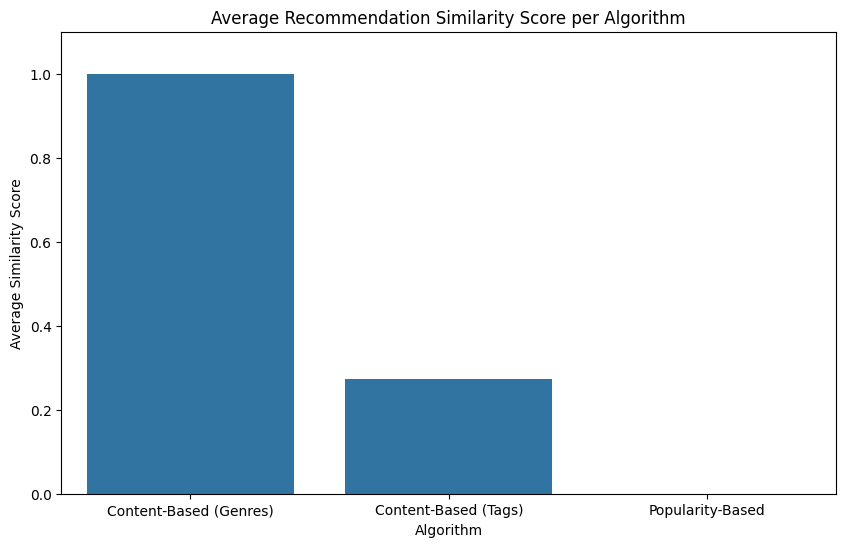

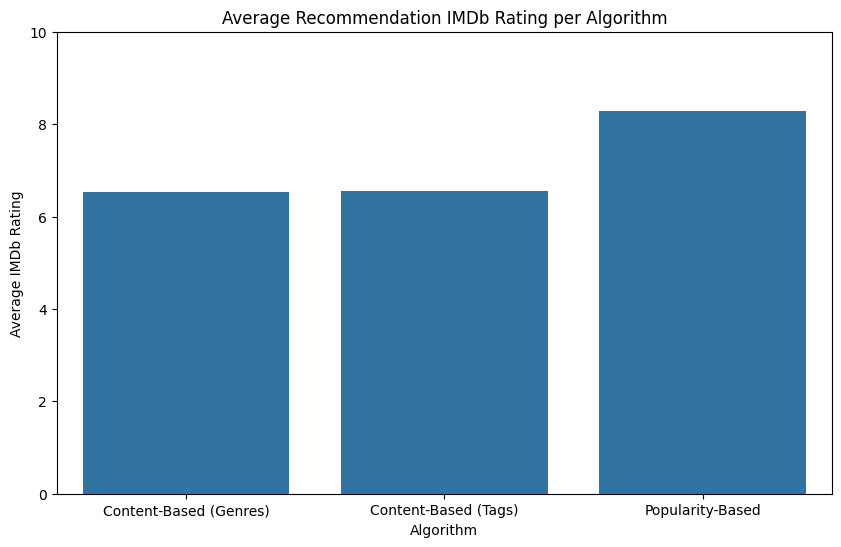

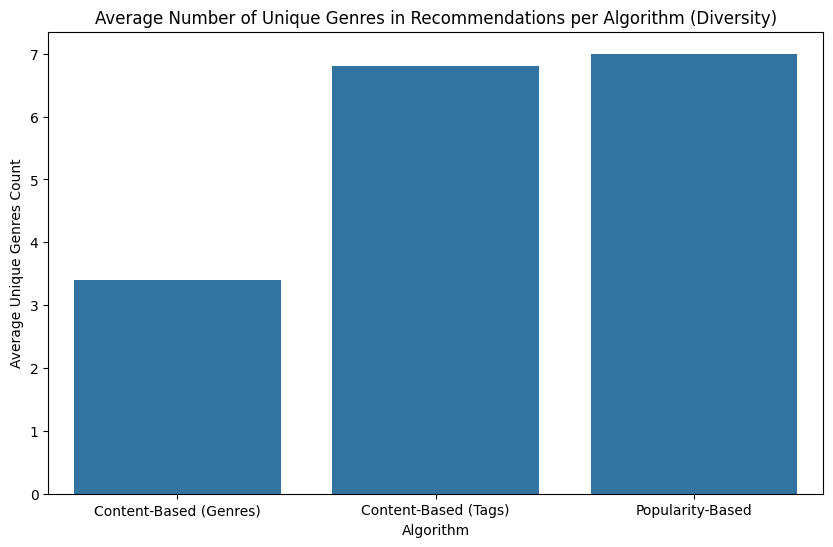

In [98]:
print("\n--- Plotting Evaluation Metrics ---")
avg_eval_results = evaluation_results.groupby('Algorithm').agg({
    'Avg Rec Similarity': 'mean',
    'Avg Rec Rating': 'mean',
    'Avg Unique Genres': 'mean'
}).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Algorithm', y='Avg Rec Similarity', data=avg_eval_results)
plt.title('Average Recommendation Similarity Score per Algorithm')
plt.ylabel('Average Similarity Score')
plt.ylim(0, avg_eval_results['Avg Rec Similarity'].max() * 1.1)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Algorithm', y='Avg Rec Rating', data=avg_eval_results)
plt.title('Average Recommendation IMDb Rating per Algorithm')
plt.ylabel('Average IMDb Rating')
plt.ylim(0, 10) # IMDb ratings are typically out of 10
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Algorithm', y='Avg Unique Genres', data=avg_eval_results)
plt.title('Average Number of Unique Genres in Recommendations per Algorithm (Diversity)')
plt.ylabel('Average Unique Genres Count')
plt.show()

## **Test Recommendations**

In [101]:
all_test_predictions = pd.DataFrame(columns=['Algorithm', 'Input Movie', 'Recommended Movies'])

for algo_name, model in models.items():
    if algo_name == 'Popularity-Based':
        recommended_titles = model.recommend()['title'].tolist()
        all_test_predictions.loc[len(all_test_predictions)] = [algo_name, 'N/A (Top Popular)', recommended_titles]
    else:
        for movie in test_movies:
            recommended_df = model.recommend(movie)
            if not recommended_df.empty:
                recommended_titles = recommended_df['title'].tolist()
            else:
                recommended_titles = [] # No recommendations found
            all_test_predictions.loc[len(all_test_predictions)] = [algo_name, movie, recommended_titles]

#print(all_test_predictions.to_string())

In [102]:
all_test_predictions

,Algorithm,Input Movie,Recommended Movies
0,Content-Based (Tags),Avatar,"[Titan A.E., Sin City, Ender's Game, Apocalypt..."
1,Content-Based (Tags),The Dark Knight Rises,"[The Dark Knight, Batman Begins, Reindeer Game..."
2,Content-Based (Tags),John Carter,"[Star Trek: Insurrection, Mission to Mars, Cap..."
3,Content-Based (Tags),Toy Story,"[The Wicked Within, Colombiana, We Need to Tal..."
4,Content-Based (Tags),Titanic,"[Captain Phillips, Moonraker, In the Heart of ..."
5,Popularity-Based,N/A (Top Popular),"[The Shawshank Redemption, Fight Club, The Dar..."
6,Content-Based (Genres),Avatar,"[Superman Returns, Man of Steel, X-Men: Days o..."
7,Content-Based (Genres),The Dark Knight Rises,"[The Dark Knight, The Fast and the Furious: To..."
8,Content-Based (Genres),John Carter,"[Avengers: Age of Ultron, The Avengers, Captai..."
9,Content-Based (Genres),Toy Story,"[Happy Feet Two, Monsters, Inc., Surf's Up, To..."
